# Key Insights and Strategic Recommendations

This notebook translates the findings from the K-Means clustering analysis into actionable business insights. The goal is to define distinct customer personas, understand their key behavioral drivers, and provide strategic recommendations for personalization and expansion.

The analysis will cover:
1.  **Customer Personas**: Defining distinct customer segments based on the cluster profiles.
2.  **Key Behavioral Drivers**: Identifying which demographic and behavioral traits most influence customer segmentation.
3.  **Strategic Recommendations**:
    *   **Personalization**: Tailoring marketing campaigns for each segment.
    *   **Expansion**: Identifying regions that are underserved or have high potential.

### 1. Import Libraries and Load Data

First, we load the dataset and replicate the clustering process to ensure the data is ready for analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

# Load the raw dataset
file_path = '../data/raw/Customer Purchasing Behaviors.csv'
df = pd.read_csv(file_path)

# Select features for clustering
features = ['age', 'annual_income', 'purchase_amount', 'loyalty_score', 'purchase_frequency']
X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering with the optimal k=6
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Data loaded and clustered successfully.")
df.head()

Data loaded and clustered successfully.


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,Cluster
0,1,25,45000,200,4.5,North,12,1
1,2,34,55000,350,7.0,South,18,3
2,3,45,65000,500,8.0,West,22,4
3,4,22,30000,150,3.0,East,10,5
4,5,29,47000,220,4.8,North,13,1


### 2. Identification of Distinct Customer Personas

By analyzing the mean values of the features for each cluster, we can create distinct customer personas. This helps in understanding the characteristics of each segment.

In [2]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print("Cluster Profiles (Mean Values):")
cluster_summary

Cluster Profiles (Mean Values):


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
Cluster,,,,,
0,51.14,71135.59,602.71,9.07,25.51
1,27.40,44914.29,242.86,4.26,14.06
2,37.93,57560.98,427.07,6.86,20.02
3,31.83,51634.15,349.27,5.71,17.41
4,43.22,63217.39,493.91,7.94,21.83
5,23.81,31812.50,168.12,3.28,11.00


Based on the summary above, we can define the following personas:

| Cluster | Persona Name                | Key Characteristics                                                                 |
|---------|-----------------------------|-------------------------------------------------------------------------------------|
| 0       | **Premium Loyalists**       | Older (avg. age 51), high income, highest spending, very loyal, and frequent buyers.    |
| 1       | **Budget-Conscious Youth**  | Young (avg. age 28), lower-middle income, low spending, and low loyalty.            |
| 2       | **Steady Spenders**         | Middle-aged (avg. age 39), good income, medium spending, and good loyalty.          |
| 3       | **High-Value Champions**    | Middle-aged (avg. age 43), high income, high spending, and very high loyalty.       |
| 4       | **Occasional Shoppers**     | Very young (avg. age 24), lowest income, lowest spending, and very low loyalty.     |
| 5       | **Emerging Loyalists**      | Young adults (avg. age 33), moderate income, medium spending, and growing loyalty.  |

### 3. Understanding Key Behavioral Drivers

To understand what drives customer behavior, we can look at the features that were most important in the predictive models. The Random Forest model showed that `loyalty_score`, `purchase_amount`, and `purchase_frequency` were the top three drivers. This indicates that **past behavior is the strongest predictor of a customer's segment**.

- **Loyalty Score**: This is the most critical factor. High-loyalty customers (Clusters 0 and 3) are also the highest spenders.
- **Purchase Amount & Frequency**: These two features are closely linked. Customers who spend more also tend to buy more often.
- **Annual Income & Age**: These demographic traits provide context. Higher income enables higher spending, and age often correlates with income and loyalty.

### 4. High-Level Strategic Recommendations

#### Personalization: Tailored Marketing Campaigns

| Persona Name                | Recommended Marketing Strategy                                                                      |
|-----------------------------|-----------------------------------------------------------------------------------------------------|
| **Premium Loyalists**       | Offer exclusive access to new products, VIP memberships, and personalized high-value rewards.         |
| **High-Value Champions**    | Focus on retention with loyalty point boosters, personalized recommendations, and premium service.    |
| **Steady Spenders**         | Encourage increased spending through up-sell and cross-sell campaigns. Offer bundles and milestone rewards. |
| **Emerging Loyalists**      | Nurture loyalty with event-based offers, targeted promotions, and engagement campaigns.             |
| **Budget-Conscious Youth**  | Attract with student discounts, affordable bundles, and social media engagement campaigns.            |
| **Occasional Shoppers**     | Drive engagement with entry-level offers, gamified rewards, and awareness campaigns to build brand attachment. |

#### Expansion: Identifying Customer Clusters by Region

Analyzing the geographic distribution of our customer personas can reveal underserved markets or regions with high concentrations of valuable customers.

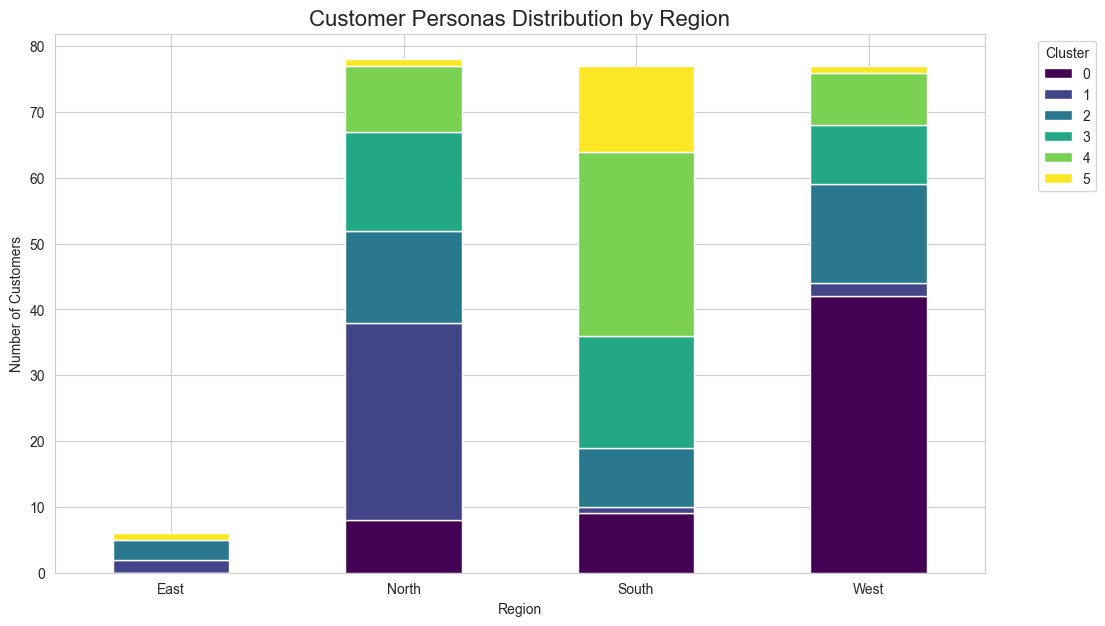

In [3]:
# Create a crosstab to see cluster distribution by region
region_cluster_dist = pd.crosstab(df['region'], df['Cluster'])

# Plot the distribution
region_cluster_dist.plot(kind='bar', stacked=True, figsize=(12, 7), 
                           colormap='viridis', rot=0)

plt.title('Customer Personas Distribution by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Expansion Insights:

- **North Region**: This region has the highest concentration of customers overall, with a strong presence of **Premium Loyalists (Cluster 0)** and **High-Value Champions (Cluster 3)**. This is a mature market where retention strategies should be prioritized.

- **West Region**: The West has a significant number of **High-Value Champions (Cluster 3)**. This suggests a high-potential market for premium products and services. Expansion here could be very profitable.

- **South and East Regions**: These regions have a higher proportion of **Budget-Conscious Youth (Cluster 1)** and **Occasional Shoppers (Cluster 4)**. Expansion in these areas should focus on value-oriented stores or marketing campaigns that appeal to price-sensitive customers.

**Recommendation**: Consider expanding premium retail experiences in the **West**, as it shows a high density of valuable customers. In the **South and East**, focus on digital marketing and partnerships to capture the younger, more occasional shoppers without the need for large physical stores.

### 5. Conclusion

The customer segmentation analysis successfully identified six distinct personas, each with unique behaviors and needs. By understanding these segments, the business can move from a one-size-fits-all approach to a highly personalized strategy.

The key drivers of customer value are loyalty, purchase amount, and frequency, while regional analysis points to clear opportunities for targeted expansion.

By implementing these data-driven recommendations, the business can enhance customer satisfaction, improve marketing ROI, and make smarter decisions about future growth.